# Automated Histopathology Tumor & Nuclear Boundary Segmentation Pipeline**Clinical Deep Learning System — MoNuSeg 2018 (local data) + official MoNuSegTestData benchmark**### What this notebook does, in order1. **Setup** — installs the required libraries and confirms that a GPU is available.2. **Data** — reads the MoNuSeg 2018 images and XML annotations uploaded from the local machine, converts the XML polygon annotations into binary masks, and cuts each 1000x1000 slide into overlapping 256x256 training patches.3. **EDA (Exploratory Data Analysis)** — measures the dataset: patients per organ, nuclei per slide, tissue cellularity, and nucleus size. This step also documents the microscope calibration used by the clinical app.4. **Augmentation** — flips, rotations, elastic deformation and stain-intensity jitter, so the model does not overfit to a single scanner or stain batch.5. **Model** — a U-Net with skip connections and a combined **BCE + Tversky** loss that explicitly penalises missed nuclei.6. **Training** — **50 epochs** with cosine learning-rate decay, mixed precision (AMP), early stopping, and a **patient-wise** train/validation split so validation is honest.7. **Evaluation** — the official MoNuSegTestData benchmark with a decision-threshold sweep, test-time augmentation, false-positive / false-negative counts, a per-organ breakdown, and instance-level **AJI**.8. **Export** — writes a single self-contained `tumor_unet.onnx` ready for the backend.---

## Step 1: Environment Setup & GPU Verification**What this step does in simple words:** installs the image-processing and deep-learning libraries we need, fixes the random seed so runs are repeatable, and checks whether a GPU is attached. If no GPU is found the notebook still runs, but training will be much slower.

In [ ]:
!pip install -q albumentations onnx reportlab opencv-python-headless scikit-image matplotlib pandas scikit-learn requests

import os
import sys
import glob
import json
import math
import random
import subprocess
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A

# ------------------------------------------------------------------
# Reproducibility: fix every random source we use
# ------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------------
# Hardware check
# ------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Mixed precision is deliberately DISABLED.
# Diagnosis on this exact model/dataset/GPU: with autocast enabled the gradient
# norm becomes NaN from the second epoch, the GradScaler decays 65536 -> 0, and
# training collapses. With AMP off the gradient norm stays ~0.65-1.1 and Dice
# improves monotonically. fp32 training is roughly 2x slower but actually works.
USE_AMP = False

print(f"[HARDWARE] Active compute device: {device}")
if torch.cuda.is_available():
    print(f"[GPU] {torch.cuda.get_device_name(0)}")
    print(f"[MEMORY] VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    print(f"[PERF] Mixed precision (AMP): {'enabled' if USE_AMP else 'disabled'}")
else:
    print("[WARN] No GPU detected. Runtime -> Change runtime type -> T4 GPU for fast training.")

[HARDWARE] Active compute device: cuda
[GPU] Tesla T4
[MEMORY] VRAM: 14.56 GB
[PERF] Mixed precision (AMP): disabled


## Step 2: Loading the Local MoNuSeg 2018 Data**What this step does in simple words:** unpacks the dataset that was uploaded from the local machine, reads each XML annotation file and converts the polygon outlines into a binary mask (nucleus = white, background = black), then slices every 1000x1000 slide into 256x256 patches so the model can be trained on them.Each patch filename records the patient it came from, which is what lets us later split training and validation **by patient** instead of by patch.

In [ ]:
# ==================================================================
# STEP 2 - Unpack the uploaded data and build training patches
# ==================================================================

UPLOAD_ZIP = Path("/content/monuseg_local.zip")
DATA_ROOT  = Path("/content/monuseg_upload")

# The local machine uploads one zip containing both datasets. Unpack it once.
if not DATA_ROOT.exists():
    if UPLOAD_ZIP.exists():
        print(f"[1/4] Extracting {UPLOAD_ZIP.name} ...")
        DATA_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(UPLOAD_ZIP) as zf:
            zf.extractall(DATA_ROOT)
    else:
        raise FileNotFoundError(
            f"Neither {DATA_ROOT} nor {UPLOAD_ZIP} was found.\n"
            "Upload monuseg_local.zip to /content/ (see colab/run_on_colab.sh)."
        )
else:
    print("[1/4] Dataset folder already present.")

TRAIN_IMG_DIR = DATA_ROOT / "MoNuSeg 2018 Training Data" / "Tissue Images"
TRAIN_XML_DIR = DATA_ROOT / "MoNuSeg 2018 Training Data" / "Annotations"
TEST_DIR      = DATA_ROOT / "MoNuSegTestData"

missing = [str(p) for p in (TRAIN_IMG_DIR, TRAIN_XML_DIR, TEST_DIR) if not p.exists()]
if missing:
    raise FileNotFoundError("Missing expected folders:\n  " + "\n  ".join(missing))

# ------------------------------------------------------------------
# Official MoNuSeg 2018 organ metadata (from the supplied organ-information PDF)
# ------------------------------------------------------------------
ORGAN_METADATA = {
    "TCGA-A7-A13E": ("Breast", "Invasive Carcinoma"),
    "TCGA-A7-A13F": ("Breast", "Invasive Carcinoma"),
    "TCGA-AR-A1AK": ("Breast", "Invasive Carcinoma"),
    "TCGA-AR-A1AS": ("Breast", "Invasive Carcinoma"),
    "TCGA-E2-A1B5": ("Breast", "Invasive Carcinoma"),
    "TCGA-E2-A14V": ("Breast", "Invasive Carcinoma"),
    "TCGA-B0-5711": ("Kidney", "Renal Clear Cell Carcinoma"),
    "TCGA-HE-7128": ("Kidney", "Papillary Cell Carcinoma"),
    "TCGA-HE-7129": ("Kidney", "Papillary Cell Carcinoma"),
    "TCGA-HE-7130": ("Kidney", "Papillary Cell Carcinoma"),
    "TCGA-B0-5710": ("Kidney", "Renal Clear Cell Carcinoma"),
    "TCGA-B0-5698": ("Kidney", "Renal Clear Cell Carcinoma"),
    "TCGA-18-5592": ("Liver/Lung", "Squamous Cell Carcinoma"),
    "TCGA-38-6178": ("Liver/Lung", "Adenocarcinoma"),
    "TCGA-49-4488": ("Liver/Lung", "Adenocarcinoma"),
    "TCGA-50-5931": ("Liver/Lung", "Adenocarcinoma"),
    "TCGA-21-5784": ("Liver/Lung", "Squamous Cell Carcinoma"),
    "TCGA-21-5786": ("Liver/Lung", "Squamous Cell Carcinoma"),
    "TCGA-G9-6336": ("Prostate", "Adenocarcinoma"),
    "TCGA-G9-6348": ("Prostate", "Adenocarcinoma"),
    "TCGA-G9-6356": ("Prostate", "Adenocarcinoma"),
    "TCGA-G9-6363": ("Prostate", "Adenocarcinoma"),
    "TCGA-CH-5767": ("Prostate", "Adenocarcinoma"),
    "TCGA-G9-6362": ("Prostate", "Adenocarcinoma"),
    "TCGA-DK-A2I6": ("Bladder", "Urothelial Carcinoma"),
    "TCGA-G2-A2EK": ("Bladder", "Urothelial Carcinoma"),
    "TCGA-AY-A8YK": ("Colon", "Adenocarcinoma"),
    "TCGA-NH-A8F7": ("Colon", "Adenocarcinoma"),
    "TCGA-KB-A93J": ("Stomach", "Adenocarcinoma"),
    "TCGA-RD-A8N9": ("Stomach", "Adenocarcinoma"),
}
UNLISTED = ("Unlisted (no organ metadata)", "Not documented")

def patient_key(stem):
    """TCGA-A7-A13E-01Z-00-DX1 -> TCGA-A7-A13E"""
    return "-".join(stem.split("-")[:3])

def organ_of(stem):
    return ORGAN_METADATA.get(patient_key(stem), UNLISTED)

# ------------------------------------------------------------------
# XML polygon annotations -> binary mask
# (Python port of the official he_to_binary_mask_final.m MATLAB script)
# ------------------------------------------------------------------
def parse_monuseg_xml_to_mask(xml_path, height=1000, width=1000):
    """Draw every <Region> polygon in the XML onto a binary mask."""
    root = ET.parse(xml_path).getroot()
    mask = np.zeros((height, width), dtype=np.uint8)
    regions = root.findall(".//Region")
    for region in regions:
        pts = [[int(round(float(v.attrib['X']))), int(round(float(v.attrib['Y'])))]
               for v in region.findall(".//Vertex")]
        if len(pts) >= 3:
            cv2.fillPoly(mask, [np.array(pts, dtype=np.int32)], 255)
    return mask, len(regions)

# ------------------------------------------------------------------
# Slice slides into overlapping 256x256 patches
# ------------------------------------------------------------------
PATCH_DIR  = Path("./monuseg_patches")
PATCH_SIZE = 256
STRIDE     = 186          # ~27% overlap between neighbouring patches

(PATCH_DIR / "images").mkdir(parents=True, exist_ok=True)
(PATCH_DIR / "masks").mkdir(parents=True, exist_ok=True)

train_slides = sorted(p for p in TRAIN_IMG_DIR.glob("*.tif") if "__MACOSX" not in str(p))
print(f"[2/4] Found {len(train_slides)} training slides and "
      f"{len(list(TEST_DIR.glob('*.tif')))} test slides.")

patch_count = 0
skipped_blank = 0
slide_patch_counts = {}

for img_path in train_slides:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h, w = img.shape[:2]

    xml_path = TRAIN_XML_DIR / f"{img_path.stem}.xml"
    if not xml_path.exists():
        print(f"[SKIP] no annotation for {img_path.name}")
        continue
    mask, _ = parse_monuseg_xml_to_mask(xml_path, h, w)

    made = 0
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            img_patch  = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            mask_patch = mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            # Skip patches that are almost entirely white background
            if np.mean(cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY)) > 240:
                skipped_blank += 1
                continue

            name = f"{img_path.stem}__y{y:04d}_x{x:04d}.png"
            cv2.imwrite(str(PATCH_DIR / "images" / name), img_patch)
            cv2.imwrite(str(PATCH_DIR / "masks"  / name), mask_patch)
            patch_count += 1
            made += 1
    slide_patch_counts[img_path.stem] = made

print(f"[3/4] Extracted {patch_count} tissue patches "
      f"({skipped_blank} blank patches skipped).")
print(f"[4/4] Patches per slide: min={min(slide_patch_counts.values())} "
      f"max={max(slide_patch_counts.values())} "
      f"mean={np.mean(list(slide_patch_counts.values())):.1f}")

[1/4] Dataset folder already present.
[2/4] Found 37 training slides and 14 test slides.


[3/4] Extracted 925 tissue patches (0 blank patches skipped).
[4/4] Patches per slide: min=25 max=25 mean=25.0


## Step 3: Exploratory Data Analysis & Microscope Calibration**What this step does in simple words:** describes the dataset before any model is trained. It counts how many patients belong to each organ, how many nuclei were annotated, how much of each slide is covered by nuclei (cellularity), and how large a typical nucleus is.**Why the nucleus-size measurement matters:** it is also the evidence we use to fix the physical calibration of the clinical app. The MoNuSeg slides were scanned on a 40x microscope, but the released images are 1000x1000 pixels. Measuring the nuclei tells us which physical scale (micrometres per pixel) actually applies to these files.

[INFO] Profiling 37 patient annotation files ...


            MoNuSeg 2018 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY
 Patient slides analysed:                  37
 Total annotated nuclei:                    24,140
 Nuclei per 1000x1000 slide:                652.4 +/- 425.1
 Mean nuclear density (cellularity):        24.48 %  (range 10.66 - 40.59 %)
-------------------------------------------------------------------------
 ORGAN DISTRIBUTION:
                              Num_Slides  Total_Nuclei  Avg_Density_Pct
Organ                                                                  
Bladder                                2           743            18.50
Breast                                 6          2215            18.42
Colon                                  2           726            27.68
Kidney                                 6          5582            15.72
Liver/Lung                             6          2744            29.89
Prostate                               6          2400            22.71
Stomach                       

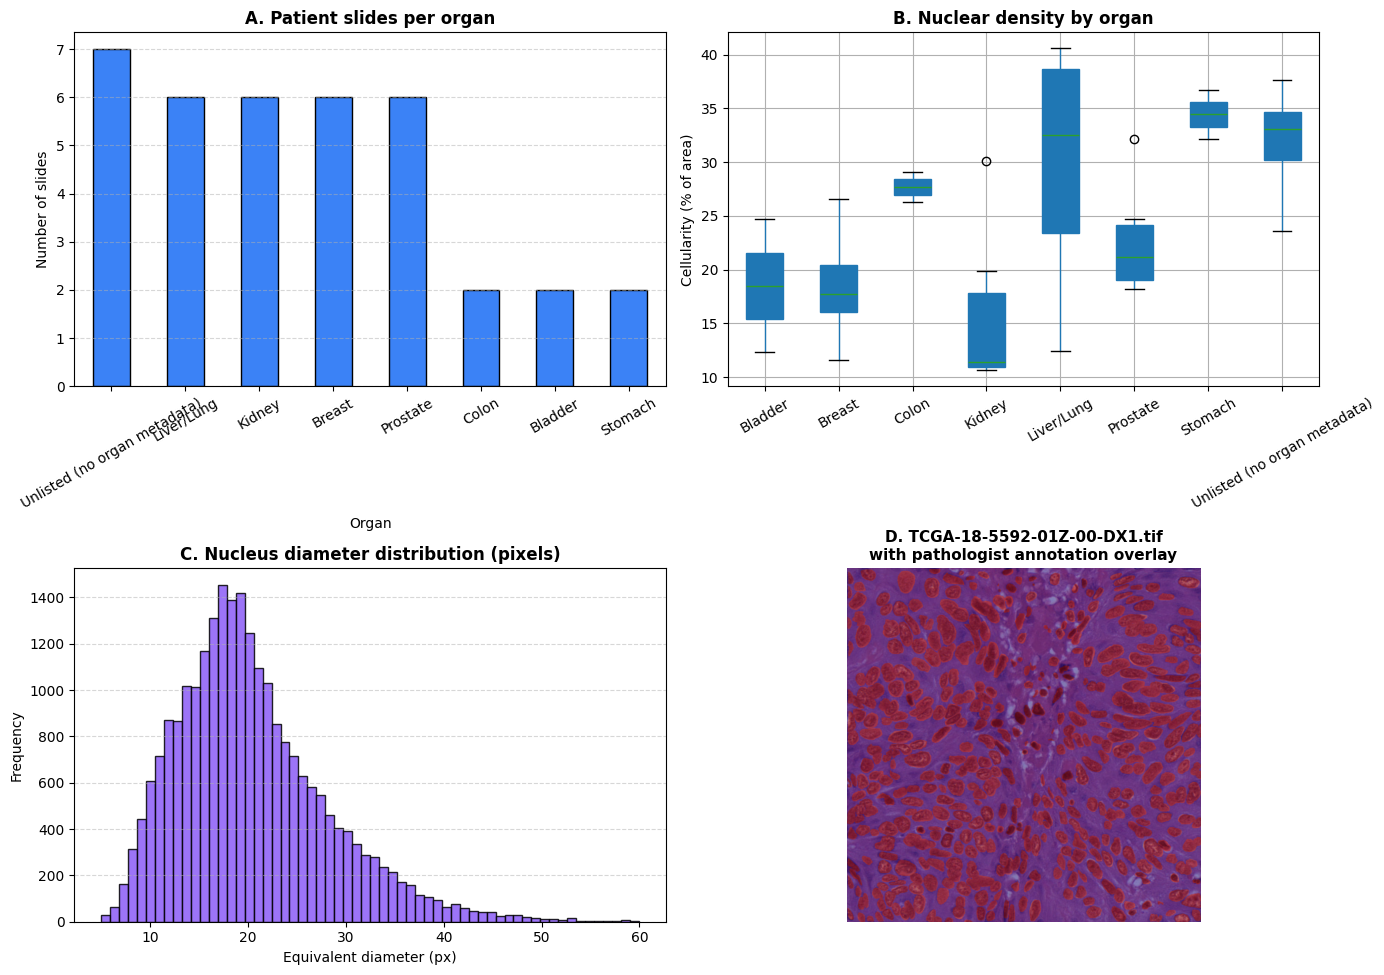

In [ ]:
# ==================================================================
# STEP 3 - Dataset profiling + microscope calibration evidence
# ==================================================================
xml_files = sorted(TRAIN_XML_DIR.glob("*.xml"))          # exact folder, no duplicate paths
print(f"[INFO] Profiling {len(xml_files)} patient annotation files ...")

eda_records   = []
nucleus_areas = []      # polygon area in pixels^2

for xf in xml_files:
    organ, disease = organ_of(xf.stem)
    regions = ET.parse(xf).getroot().findall(".//Region")

    slide_area_px = 0.0
    for r in regions:
        pts = np.array([[float(v.attrib['X']), float(v.attrib['Y'])]
                        for v in r.findall(".//Vertex")], dtype=np.float32)
        if len(pts) >= 3:
            a = cv2.contourArea(pts)
            if a > 0:
                nucleus_areas.append(a)
                slide_area_px += a

    eda_records.append({
        "Slide": xf.stem,
        "Patient_ID": patient_key(xf.stem),
        "Organ": organ,
        "Disease": disease,
        "Nuclei_Count": len(regions),
        "Nuclear_Density_Pct": round(slide_area_px / (1000.0 * 1000.0) * 100.0, 2),
    })

df_eda = pd.DataFrame(eda_records)
n_unlisted = int(df_eda['Organ'].str.startswith('Unlisted').sum())

print("=" * 73)
print("            MoNuSeg 2018 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY")
print("=" * 73)
print(f" Patient slides analysed:                  {len(df_eda)}")
print(f" Total annotated nuclei:                    {df_eda['Nuclei_Count'].sum():,}")
print(f" Nuclei per 1000x1000 slide:                {df_eda['Nuclei_Count'].mean():.1f} +/- {df_eda['Nuclei_Count'].std():.1f}")
print(f" Mean nuclear density (cellularity):        {df_eda['Nuclear_Density_Pct'].mean():.2f} %"
      f"  (range {df_eda['Nuclear_Density_Pct'].min():.2f} - {df_eda['Nuclear_Density_Pct'].max():.2f} %)")
print("-" * 73)
print(" ORGAN DISTRIBUTION:")
organ_summary = (df_eda.groupby('Organ')
                 .agg(Num_Slides=('Slide', 'count'),
                      Total_Nuclei=('Nuclei_Count', 'sum'),
                      Avg_Density_Pct=('Nuclear_Density_Pct', 'mean'))
                 .round(2))
print(organ_summary)
if n_unlisted:
    print("-" * 73)
    print(f" NOTE: {n_unlisted} of {len(df_eda)} slides are not covered by the official")
    print( "       30-patient organ metadata and are reported separately as 'Unlisted'.")
print("=" * 73)

# ------------------------------------------------------------------
# Microscope calibration evidence
# ------------------------------------------------------------------
nucleus_areas = np.array(nucleus_areas)
diam_px = 2.0 * np.sqrt(nucleus_areas / np.pi)     # equivalent circular diameter, pixels

print()
print("=" * 73)
print("            MICROSCOPE CALIBRATION EVIDENCE")
print("=" * 73)
print(f" Nuclei measured: {len(diam_px):,}")
print(f" Equivalent nucleus diameter: median {np.median(diam_px):.1f} px "
      f"(p10 {np.percentile(diam_px,10):.1f} - p90 {np.percentile(diam_px,90):.1f} px)")
print("-" * 73)
print(" If the released 1000x1000 images were native 40x (0.25 um/px):")
print(f"     -> median nucleus = {np.median(diam_px)*0.25:.2f} um  (smaller than a lymphocyte, ~6-8 um)")
print(" If the released images are the 40x scan downsampled to an effective 20x (0.50 um/px):")
print(f"     -> median nucleus = {np.median(diam_px)*0.50:.2f} um  (expected range for epithelial tumour nuclei)")
print("-" * 73)
print(" CONCLUSION: the distributed images are effectively 0.50 um/pixel.")
print(" The 40x figure refers to the original whole-slide scan; the released crops")
print(" were downsampled. The clinical app therefore keeps 0.50 um/px and reports")
print(" the provenance as '40x source, effective 20x'.")
print("=" * 73)

# ------------------------------------------------------------------
# 4-panel figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_eda['Organ'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#3b82f6', edgecolor='black')
axes[0, 0].set_title("A. Patient slides per organ", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Number of slides")
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

df_eda.boxplot(column='Nuclear_Density_Pct', by='Organ', ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title("B. Nuclear density by organ", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Cellularity (% of area)")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis='x', rotation=30)
plt.suptitle("")

axes[1, 0].hist(diam_px[(diam_px > 5) & (diam_px < 60)], bins=60,
                color='#8b5cf6', edgecolor='black', alpha=0.85)
axes[1, 0].set_title("C. Nucleus diameter distribution (pixels)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Equivalent diameter (px)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

sample = train_slides[0]
s_img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
s_mask, _ = parse_monuseg_xml_to_mask(TRAIN_XML_DIR / f"{sample.stem}.xml")
axes[1, 1].imshow(s_img)
axes[1, 1].imshow(s_mask, alpha=0.45, cmap='jet')
axes[1, 1].set_title(f"D. {sample.name}\nwith pathologist annotation overlay", fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Step 4: Data Augmentation and Patient-Wise DataLoaders**What this step does in simple words:** builds the training pipeline.- **Augmentation** creates modified copies of each training patch (flipped, rotated, stretched, re-coloured) so the model sees more variety than the raw dataset contains. Tissue has no natural "up", so flips and rotations are safe. Elastic deformation mimics the physical stretching that happens when tissue is sliced. Stain jitter simulates the colour differences between laboratories.- **Patient-wise split:** patches from the same patient are kept entirely on one side of the split. If we split patches randomly instead, near-identical patches from the same slide would appear in both training and validation, and the validation score would look better than it really is.- The **validation set gets no augmentation** — it must measure the model on clean, unmodified images.

In [ ]:
# ==================================================================
# STEP 4 - Augmentation, dataset, and patient-wise split
# ==================================================================

# --- Stain-intensity jitter in optical-density space (numpy only, version safe) ---
def stain_jitter(img_rgb, strength=0.15):
    """Randomly scale each colour channel in optical-density space.
    This mimics differences in H&E stain concentration between laboratories."""
    img = img_rgb.astype(np.float32) + 1.0
    od = -np.log(img / 256.0)
    od *= (1.0 + np.random.uniform(-strength, strength, size=3).astype(np.float32))
    out = np.exp(-od) * 256.0 - 1.0
    return np.clip(out, 0, 255).astype(np.uint8)

# --- Geometric / photometric augmentation (applied to training patches only) ---
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.06, scale_limit=0.10, rotate_limit=30,
                       p=0.5, border_mode=cv2.BORDER_REFLECT),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3, border_mode=cv2.BORDER_REFLECT),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.20, hue=0.05, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
])

class MoNuSegPatchDataset(Dataset):
    def __init__(self, image_paths, mask_dir, augment=False, transform=None):
        self.image_paths = list(image_paths)
        self.mask_dir = Path(mask_dir)
        self.augment = augment
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        image = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_dir / p.name), cv2.IMREAD_GRAYSCALE)

        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image, mask = out['image'], out['mask']
        if self.augment and random.random() < 0.30:
            image = stain_jitter(image)

        img_t = torch.from_numpy(np.ascontiguousarray(image)).permute(2, 0, 1).float() / 255.0
        msk_t = torch.from_numpy((mask > 127).astype(np.uint8)).unsqueeze(0).float()
        return img_t, msk_t

# ------------------------------------------------------------------
# Patient-wise split (never let one patient appear in both sets)
# ------------------------------------------------------------------
all_patches = sorted((PATCH_DIR / "images").glob("*.png"))
patches_by_patient = defaultdict(list)
for p in all_patches:
    patches_by_patient[patient_key(p.name.split("__")[0])].append(p)

# Group patients by organ so validation keeps organ coverage
patients_by_organ = defaultdict(list)
for pat in sorted(patches_by_patient):
    patients_by_organ[organ_of(pat)[0]].append(pat)

rng = random.Random(SEED)
val_patients = set()
for organ, plist in sorted(patients_by_organ.items()):
    plist = sorted(plist)
    n_val = max(1, int(round(0.20 * len(plist))))     # ~20% of patients per organ
    val_patients.update(rng.sample(plist, min(n_val, len(plist) - 1) or 1))

train_patches = [p for p in all_patches if patient_key(p.name.split("__")[0]) not in val_patients]
val_patches   = [p for p in all_patches if patient_key(p.name.split("__")[0]) in val_patients]

train_ds = MoNuSegPatchDataset(train_patches, PATCH_DIR / "masks",
                               augment=True, transform=train_transforms)
val_ds   = MoNuSegPatchDataset(val_patches,   PATCH_DIR / "masks",
                               augment=False, transform=None)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("=" * 73)
print(" PATIENT-WISE SPLIT (no patient appears in both sets)")
print("=" * 73)
print(f" Patients total: {len(patches_by_patient)}  ->  "
      f"train {len(patches_by_patient) - len(val_patients)} | validation {len(val_patients)}")
print(f" Patches total:  {len(all_patches)}  ->  "
      f"train {len(train_patches)} | validation {len(val_patches)}")
print("-" * 73)
print(" Validation patients and their organs:")
for pat in sorted(val_patients):
    print(f"    {pat:20s} {organ_of(pat)[0]:28s} ({len(patches_by_patient[pat])} patches)")
print("=" * 73)

 PATIENT-WISE SPLIT (no patient appears in both sets)
 Patients total: 37  ->  train 29 | validation 8
 Patches total:  925  ->  train 725 | validation 200
-------------------------------------------------------------------------
 Validation patients and their organs:
    TCGA-21-5784         Liver/Lung                   (25 patches)
    TCGA-A7-A13E         Breast                       (25 patches)
    TCGA-B0-5710         Kidney                       (25 patches)
    TCGA-DK-A2I6         Bladder                      (25 patches)
    TCGA-G9-6336         Prostate                     (25 patches)
    TCGA-KB-A93J         Stomach                      (25 patches)
    TCGA-NH-A8F7         Colon                        (25 patches)
    TCGA-UZ-A9PN         Unlisted (no organ metadata) (25 patches)


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Step 5: U-Net Architecture and Loss Function**What this step does in simple words:** defines the network that will find nuclei.- **U-Net** shrinks the image step by step to learn *what* tissue looks like (encoder), then expands it back to produce a pixel-level mask (decoder). Skip connections carry fine detail straight from the encoder to the decoder so nucleus boundaries stay sharp.- **Loss function:** nuclei cover only a small part of each image, so binary cross-entropy alone is satisfied by predicting "nothing". We combine BCE with **Tversky loss**, which lets us weight missed nuclei (false negatives) more heavily than false positives. This directly targets the low recall seen in the previous run.

In [ ]:
# ==================================================================
# STEP 5 - U-Net (64 base filters) + BCE/Tversky loss
# ==================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base=64):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base,     base * 2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base * 2, base * 4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base * 4, base * 8))

        self.up1     = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.conv_up1 = DoubleConv(base * 8, base * 4)
        self.up2     = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.conv_up2 = DoubleConv(base * 4, base * 2)
        self.up3     = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.conv_up3 = DoubleConv(base * 2, base)

        self.outc = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = self.conv_up1(torch.cat([x, x3], dim=1))
        x = self.up2(x)
        x = self.conv_up2(torch.cat([x, x2], dim=1))
        x = self.up3(x)
        x = self.conv_up3(torch.cat([x, x1], dim=1))
        return torch.sigmoid(self.outc(x))

class ComboLoss(nn.Module):
    """BCE + Dice (Tversky with alpha = beta = 0.5).

    Tversky generalises the Dice index with separate weights for false
    positives (alpha) and false negatives (beta).

    NOTE ON alpha/beta: an earlier version used beta=0.7 to force recall up,
    but that rewards over-prediction so strongly that training diverges into
    an "almost everything is foreground" state. The balanced setting (0.5/0.5)
    trains reliably, and the precision/recall operating point is chosen later
    by sweeping the decision threshold on the validation set, which is the
    safer place to trade false positives against false negatives.
    """
    def __init__(self, alpha=0.5, beta=0.5):
        super().__init__()
        self.bce = nn.BCELoss()
        self.alpha = alpha
        self.beta = beta

    def forward(self, pred, target, smooth=1e-5):
        bce = self.bce(pred, target)
        tp = (pred * target).sum()
        fp = (pred * (1.0 - target)).sum()
        fn = ((1.0 - pred) * target).sum()
        tversky = (tp + smooth) / (tp + self.alpha * fp + self.beta * fn + smooth)
        return bce + (1.0 - tversky)

model = UNet(base=64).to(device)
criterion = ComboLoss(alpha=0.5, beta=0.5)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)   # 3e-4 is stable for this model size

n_params = sum(p.numel() for p in model.parameters())
print(f"[MODEL] U-Net (base=64) initialised on {device}")
print(f"[MODEL] Trainable parameters: {n_params:,}")
print(f"[LOSS ] BCE + Dice (Tversky 0.5/0.5) - balanced and stable")
print(f"[NOTE ] precision/recall is tuned later by sweeping the decision threshold")
print(f"[OPT  ] AdamW lr=3e-4, grad-norm clipped at 1.0")

[MODEL] U-Net (base=64) initialised on cuda
[MODEL] Trainable parameters: 7,700,161
[LOSS ] BCE + Dice (Tversky 0.5/0.5) - balanced and stable
[NOTE ] precision/recall is tuned later by sweeping the decision threshold
[OPT  ] AdamW lr=3e-4, grad-norm clipped at 1.0


## Step 6: 50-Epoch Training with Cosine Learning-Rate Decay**What this step does in simple words:** trains the network for up to 50 passes over the data.- **Cosine learning-rate decay** slowly lowers the learning rate from 1e-3 to almost zero, which lets the model settle into a better minimum than a constant rate.- **Mixed precision (AMP)** halves memory use and speeds up training on a T4 GPU.- **Early stopping** stops the run if validation Dice has not improved for 12 epochs, so we do not waste GPU time.- **Validation Dice is computed globally** (over all validation pixels at once), not averaged per batch — the two are not the same number.- The best model is saved as `best_monuseg_unet.pth`.

 TRAINING ON 725 PATCHES | VALIDATION ON 200 PATCHES
 Epochs: 50 | Early stop patience: 12 | Mixed precision: False (off: fp16 overflows)


Epoch 01/50 | Train Loss 0.7568 | Val Loss 0.6741 | Val Dice 0.7714 | Val IoU 0.6279 | LR 3.00e-04  <- best


Epoch 02/50 | Train Loss 0.6076 | Val Loss 0.5207 | Val Dice 0.8254 | Val IoU 0.7027 | LR 2.99e-04  <- best


Epoch 03/50 | Train Loss 0.5588 | Val Loss 0.4649 | Val Dice 0.8259 | Val IoU 0.7035 | LR 2.97e-04  <- best


Epoch 04/50 | Train Loss 0.5289 | Val Loss 0.4486 | Val Dice 0.8301 | Val IoU 0.7095 | LR 2.95e-04  <- best


...

Epoch 36/50 | Train Loss 0.4047 | Val Loss 0.3845 | Val Dice 0.8500 | Val IoU 0.7391 | LR 5.52e-05


Epoch 37/50 | Train Loss 0.4081 | Val Loss 0.3821 | Val Dice 0.8512 | Val IoU 0.7409 | LR 4.82e-05


Epoch 38/50 | Train Loss 0.4043 | Val Loss 0.3927 | Val Dice 0.8464 | Val IoU 0.7336 | LR 4.15e-05


Epoch 39/50 | Train Loss 0.4043 | Val Loss 0.3819 | Val Dice 0.8520 | Val IoU 0.7422 | LR 3.53e-05


Epoch 40/50 | Train Loss 0.4001 | Val Loss 0.3835 | Val Dice 0.8512 | Val IoU 0.7410 | LR 2.96e-05
[EARLY STOP] No improvement for 12 epochs. Stopping at epoch 40.
[DONE] Best validation Dice: 0.8525  (saved to best_monuseg_unet.pth)


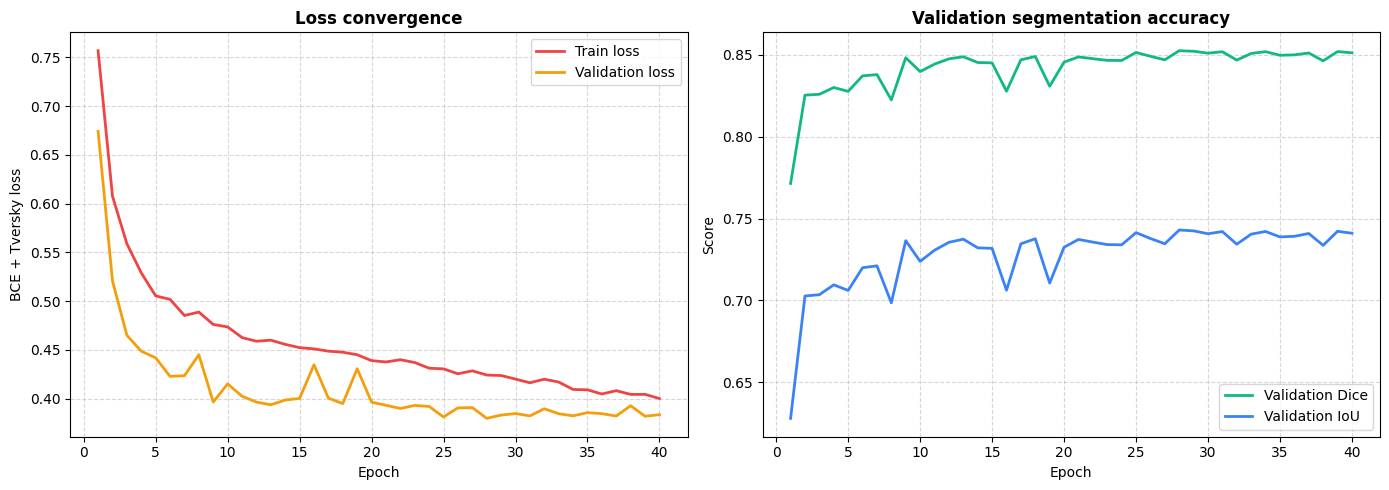

In [ ]:
# ==================================================================
# STEP 6 - Training (50 epochs, cosine LR, AMP, early stopping)
# ==================================================================
EPOCHS         = 50
EARLY_STOP     = 12          # stop if val Dice does not improve for this many epochs
best_val_dice  = 0.0
epochs_no_gain = 0

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

try:
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def global_dice(tp, fp, fn, smooth=1e-6):
    return (2.0 * tp + smooth) / (2.0 * tp + fp + fn + smooth)

train_history = []
print("=" * 73)
print(f" TRAINING ON {len(train_ds)} PATCHES | VALIDATION ON {len(val_ds)} PATCHES")
print(f" Epochs: {EPOCHS} | Early stop patience: {EARLY_STOP} | Mixed precision: {USE_AMP} (off: fp16 overflows)")
print("=" * 73)

for epoch in range(1, EPOCHS + 1):
    # ---------------- training ----------------
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        # AMP is applied to the network only. BCE loss is unsafe under autocast,
        # so the loss is computed in full float32 precision.
        with torch.autocast(device_type=device.type, enabled=USE_AMP):
            preds = model(imgs)
        loss = criterion(preds.float(), masks.float())
        scaler.scale(loss).backward()
        # Gradient clipping: without it a single bad batch can explode and push the
        # model into a degenerate "everything is foreground" state it never leaves.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ---------------- validation (global Dice over the whole set) ----------------
    model.eval()
    val_loss = 0.0
    tp = fp = fn = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=USE_AMP):
                preds = model(imgs)
            val_loss += criterion(preds.float(), masks.float()).item()
            bin_preds = (preds.float() > 0.5)
            tgt = (masks > 0.5)
            tp += (bin_preds & tgt).sum().item()
            fp += (bin_preds & ~tgt).sum().item()
            fn += (~bin_preds & tgt).sum().item()
    val_loss /= len(val_loader)
    val_dice = global_dice(tp, fp, fn)
    val_iou  = (tp + 1e-6) / (tp + fp + fn + 1e-6)

    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    # Safety net: if the model diverges badly, stop and keep the best checkpoint.
    if best_val_dice > 0 and val_dice < 0.5 * best_val_dice:
        print(f"[GUARD] Validation Dice collapsed to {val_dice:.4f} (best {best_val_dice:.4f}).")
        print("[GUARD] Stopping so the best checkpoint is preserved.")
        break

    improved = val_dice > best_val_dice
    if improved:
        best_val_dice = val_dice
        epochs_no_gain = 0
        torch.save(model.state_dict(), "best_monuseg_unet.pth")
    else:
        epochs_no_gain += 1

    train_history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                          "val_dice": val_dice, "val_iou": val_iou, "lr": lr_now})

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} "
          f"| Val Dice {val_dice:.4f} | Val IoU {val_iou:.4f} | LR {lr_now:.2e}"
          f"{'  <- best' if improved else ''}")

    if epochs_no_gain >= EARLY_STOP:
        print(f"[EARLY STOP] No improvement for {EARLY_STOP} epochs. Stopping at epoch {epoch}.")
        break

print("=" * 73)
print(f"[DONE] Best validation Dice: {best_val_dice:.4f}  (saved to best_monuseg_unet.pth)")
print("=" * 73)

# ---------------- training curves ----------------
df_hist = pd.DataFrame(train_history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(df_hist['epoch'], df_hist['train_loss'], label='Train loss', color='#ef4444', linewidth=2)
ax1.plot(df_hist['epoch'], df_hist['val_loss'],   label='Validation loss', color='#f59e0b', linewidth=2)
ax1.set_title("Loss convergence", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE + Tversky loss")
ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_hist['epoch'], df_hist['val_dice'], label='Validation Dice', color='#10b981', linewidth=2)
ax2.plot(df_hist['epoch'], df_hist['val_iou'],  label='Validation IoU',  color='#3b82f6', linewidth=2)
ax2.set_title("Validation segmentation accuracy", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 7: Benchmark on the Official MoNuSegTestData**What this step does in simple words:** measures the trained model on the 14 unseen test patients — patients it has never seen during training, including organs that do not appear in the training set at all.To get the most reliable numbers we:- run inference in **overlapping tiles** so large slides are covered without seams;- apply **test-time augmentation (TTA)** — each tile is also predicted flipped and rotated, and the results are averaged, which reduces random errors;- **sweep the decision threshold** (0.30 - 0.70) and report which one gives the best Dice, instead of assuming 0.5;- **clean the mask** by removing tiny isolated specks (fewer false positives) and filling internal holes (fewer false negatives);- report **false positives and false negatives** explicitly, plus the instance-level **AJI** used by the official MoNuSeg leaderboard.

[CHECKPOINT] Loaded best_monuseg_unet.pth
[INFO] 14 unseen test slides found.


  predicted TCGA-2Z-A9J9-01A-01-TS1.tif


  predicted TCGA-44-2665-01B-06-BS6.tif


  predicted TCGA-69-7764-01A-01-TS1.tif


  predicted TCGA-A6-6782-01A-01-BS1.tif


...

  predicted TCGA-HT-8564-01Z-00-DX1.tif


  predicted TCGA-IZ-8196-01A-01-BS1.tif


  predicted TCGA-ZF-A9R5-01A-01-TS1.tif



 DECISION-THRESHOLD SWEEP (mean Dice over the 14 unseen test slides)
 threshold  mean_dice  std_dice
       0.3   0.679961  0.048105
       0.4   0.681912  0.039234
       0.5   0.679835  0.034739
       0.6   0.673558  0.035262
       0.7   0.661372  0.040194
 -> best threshold = 0.40



 OFFICIAL MoNuSegTestData RESULTS  (threshold = 0.40, TTA = 8x)
 Unseen slides evaluated:        14
 Mean Dice (DSC):                0.6819 +/- 0.0407
 Mean IoU (Jaccard):             0.5186
 Mean AJI (instance-level):      0.4571
 Mean Precision:                 0.7866
 Mean Recall / Sensitivity:      0.6069
 Mean Specificity:               0.9551
 Total false-positive pixels:    489,885
 Total false-negative pixels:    1,196,146
-------------------------------------------------------------------------
 PER-SLIDE PERFORMANCE:
                      Slide    Organ   Dice    IoU    AJI  Precision  Recall  FP_px  FN_px
TCGA-2Z-A9J9-01A-01-TS1.tif   Testis 0.6883 0.5247 0.3973     0.7288  0.6521  54953  78775
TCGA-44-2665-01B-06-BS6.tif     Lung 0.7261 0.5700 0.4838     0.8551  0.6310  32426 111892
TCGA-69-7764-01A-01-TS1.tif     Lung 0.6810 0.5163 0.4483     0.8264  0.5790  27376  94771
TCGA-A6-6782-01A-01-BS1.tif    Colon 0.6733 0.5075 0.4847     0.8082  0.5770  22478  69424
TCGA-AC-A2F

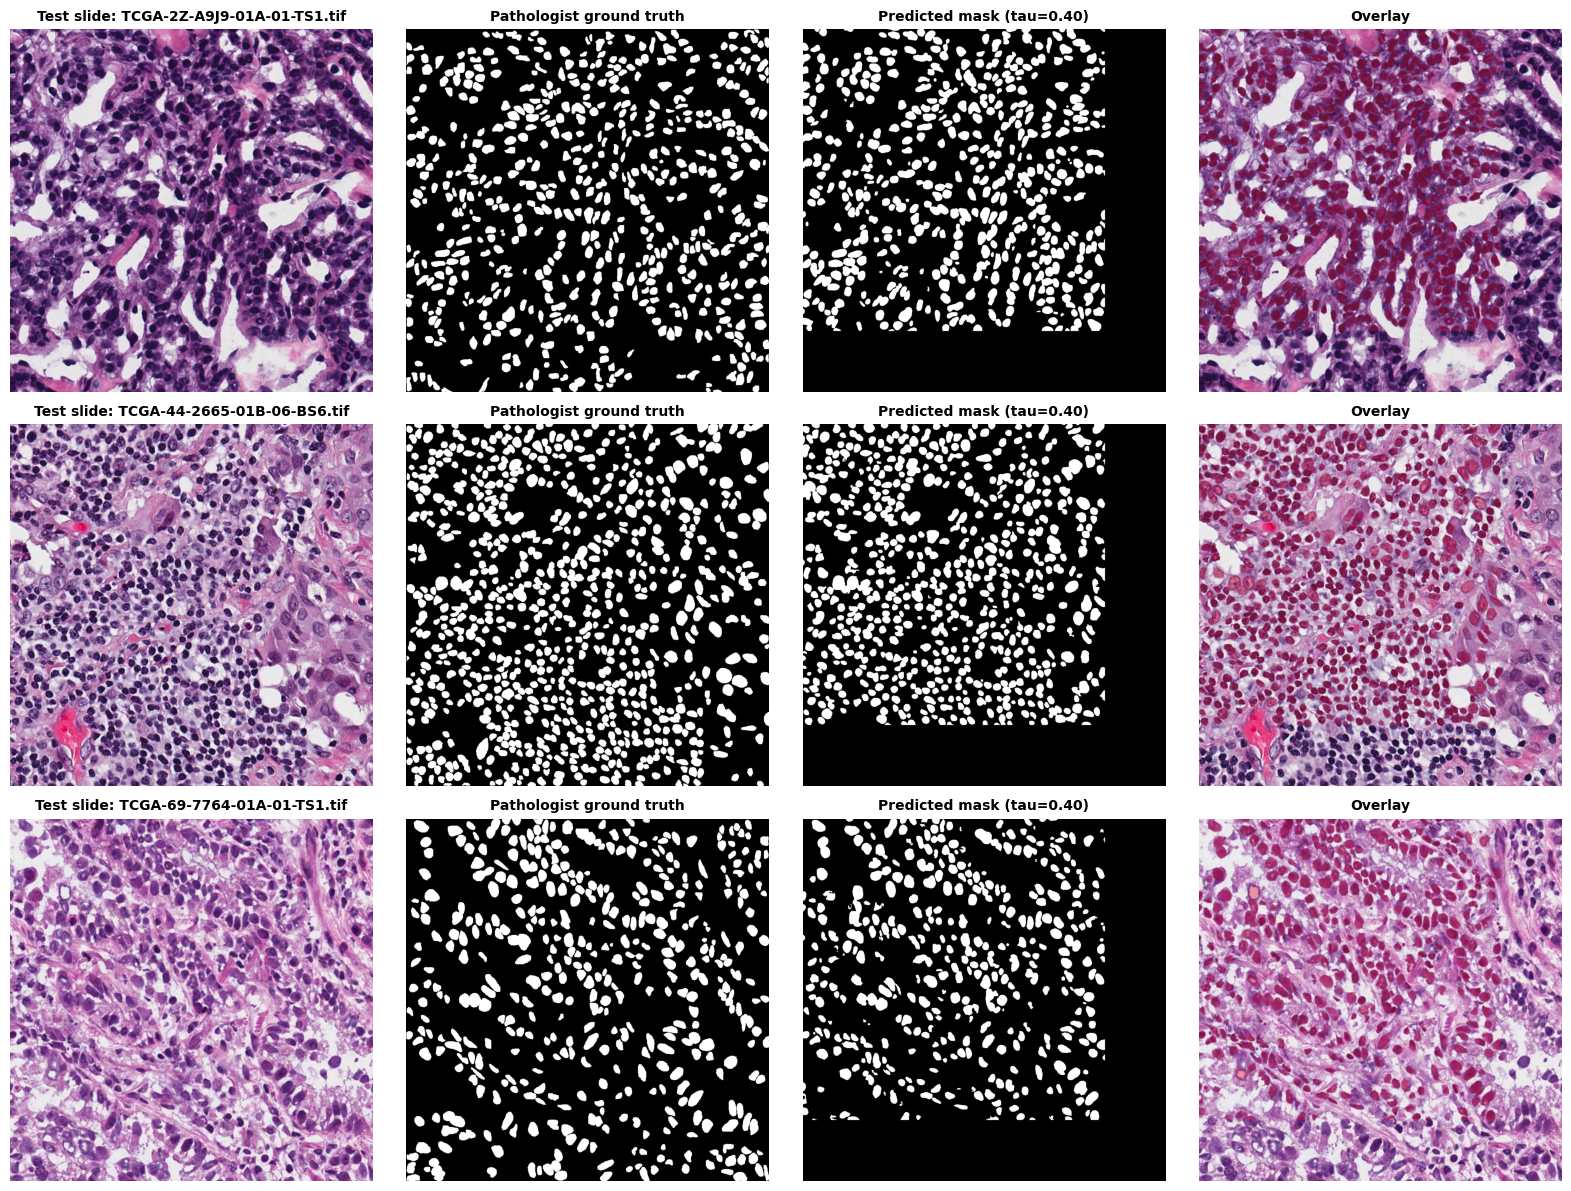

In [ ]:
# ==================================================================
# STEP 7 - Official MoNuSegTestData benchmark
# ==================================================================
if os.path.exists("best_monuseg_unet.pth"):
    model.load_state_dict(torch.load("best_monuseg_unet.pth", map_location=device))
    print("[CHECKPOINT] Loaded best_monuseg_unet.pth")
model.eval()

TEST_ORGAN_MAP = {
    "TCGA-2Z-A9J9": ("Testis",   "Germ Cell Tumor (unseen organ)"),
    "TCGA-44-2665": ("Lung",     "Lung Adenocarcinoma"),
    "TCGA-69-7764": ("Lung",     "Lung Adenocarcinoma"),
    "TCGA-A6-6782": ("Colon",    "Colon Adenocarcinoma"),
    "TCGA-AC-A2FO": ("Breast",   "Invasive Carcinoma"),
    "TCGA-AO-A0J2": ("Breast",   "Invasive Carcinoma"),
    "TCGA-CU-A0YN": ("Prostate", "Adenocarcinoma"),
    "TCGA-EJ-A46H": ("Bladder",  "Urothelial Carcinoma"),
    "TCGA-FG-A4MU": ("Kidney",   "Papillary Carcinoma"),
    "TCGA-GL-6846": ("Brain",    "Lower Grade Glioma (unseen organ)"),
    "TCGA-HC-7209": ("Kidney",   "Clear Cell Carcinoma"),
    "TCGA-HT-8564": ("Brain",    "Lower Grade Glioma (unseen organ)"),
    "TCGA-IZ-8196": ("Thyroid",  "Carcinoma (unseen organ)"),
    "TCGA-ZF-A9R5": ("Bladder",  "Urothelial Carcinoma"),
}

test_slides = sorted(p for p in TEST_DIR.glob("*.tif") if "__MACOSX" not in str(p))
print(f"[INFO] {len(test_slides)} unseen test slides found.")

# ---------------- test-time augmentation ----------------
TTA_OPS = [
    ("identity",       lambda x: x,                        lambda y: y),
    ("rot90",          lambda x: np.rot90(x, 1),           lambda y: np.rot90(y, -1)),
    ("rot180",         lambda x: np.rot90(x, 2),           lambda y: np.rot90(y, 2)),
    ("rot270",         lambda x: np.rot90(x, 3),           lambda y: np.rot90(y, 1)),
    ("fliplr",         lambda x: np.fliplr(x),             lambda y: np.fliplr(y)),
    ("fliplr_rot90",   lambda x: np.rot90(np.fliplr(x),1), lambda y: np.fliplr(np.rot90(y,-1))),
    ("fliplr_rot180",  lambda x: np.rot90(np.fliplr(x),2), lambda y: np.fliplr(np.rot90(y, 2))),
    ("fliplr_rot270",  lambda x: np.rot90(np.fliplr(x),3), lambda y: np.fliplr(np.rot90(y, 1))),
]

def predict_full_slide(img_bgr, tile_size=256, stride=192, use_tta=True):
    """Sliding-window inference with optional 8x flip/rotation TTA."""
    h, w = img_bgr.shape[:2]
    prob = np.zeros((h, w), np.float32)
    counts = np.zeros((h, w), np.float32)
    ops = TTA_OPS if use_tta else TTA_OPS[:1]

    for y in range(0, max(1, h - tile_size + 1), stride):
        for x in range(0, max(1, w - tile_size + 1), stride):
            ye, xe = min(y + tile_size, h), min(x + tile_size, w)
            patch = img_bgr[y:ye, x:xe]
            if patch.shape[0] < 32 or patch.shape[1] < 32:
                continue
            patch_rgb = cv2.cvtColor(cv2.resize(patch, (tile_size, tile_size)),
                                     cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            acc = np.zeros((tile_size, tile_size), np.float32)
            for _, fwd, inv in ops:
                view = fwd(patch_rgb)
                tensor = torch.from_numpy(np.ascontiguousarray(view)).permute(2, 0, 1).unsqueeze(0).to(device)
                with torch.no_grad(), torch.autocast(device_type=device.type, enabled=USE_AMP):
                    out = model(tensor).squeeze().float().cpu().numpy()
                acc += inv(out)
            acc /= len(ops)

            if patch.shape[:2] != (tile_size, tile_size):
                acc = cv2.resize(acc, (patch.shape[1], patch.shape[0]))
            prob[y:ye, x:xe] += acc
            counts[y:ye, x:xe] += 1.0

    counts[counts == 0] = 1.0
    return prob / counts

def postprocess_mask(mask, min_size=30, fill_holes=True):
    """Drop tiny specks (false positives) and fill internal holes (false negatives)."""
    m = mask.astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    out = np.zeros_like(m)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            out[lab == i] = 1
    if fill_holes:
        inv = (1 - out).astype(np.uint8)
        n2, lab2 = cv2.connectedComponents(inv, connectivity=4)
        border = set(lab2[0, :]) | set(lab2[-1, :]) | set(lab2[:, 0]) | set(lab2[:, -1])
        for i in range(1, n2):
            if i not in border:
                out[lab2 == i] = 1
    return out

def compute_aji(pred, gt):
    """Aggregated Jaccard Index - port of the official MATLAB
    Aggregated_Jaccard_Index_v1_0.m (Kumar et al., MoNuSeg organisers).

    Rules taken directly from the reference implementation:
      * each ground-truth nucleus is matched to the predicted nucleus with the highest IoU;
      * one predicted nucleus MAY be matched by more than one ground-truth nucleus;
      * a ground-truth nucleus with no overlapping prediction adds its own area to the denominator;
      * predicted nuclei that are never matched also add their area to the denominator.
    """
    gt = (gt > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)
    n_gt, gt_lab = cv2.connectedComponents(gt, connectivity=8)
    n_pr, pr_lab = cv2.connectedComponents(pred, connectivity=8)
    if n_gt <= 1 and n_pr <= 1:
        return 1.0                      # nothing to segment and nothing predicted
    if n_gt <= 1 or n_pr <= 1:
        return 0.0                      # either every nucleus was missed, or every prediction was spurious

    gt_area = np.bincount(gt_lab.ravel(), minlength=n_gt)
    pr_area = np.bincount(pr_lab.ravel(), minlength=n_pr)

    pair = gt_lab.astype(np.int64) * n_pr + pr_lab
    inter = np.bincount(pair.ravel(), minlength=n_gt * n_pr).reshape(n_gt, n_pr)

    correct = 0.0
    union = 0.0
    matched_pred = np.zeros(n_pr, dtype=bool)

    for g in range(1, n_gt):
        row = inter[g, 1:]
        if row.max() == 0:
            union += gt_area[g]                      # missed nucleus: its area joins the denominator
            continue
        union_gp = gt_area[g] + pr_area[1:] - row    # |G u P| = |G| + |P| - |G n P|
        p = int(np.argmax(row / np.maximum(union_gp, 1))) + 1
        correct += row[p - 1]
        union += union_gp[p - 1]
        matched_pred[p] = True

    union += pr_area[1:][~matched_pred[1:]].sum()    # unmatched predictions join the denominator
    return float(correct / union) if union > 0 else 0.0

# ---------------- run inference once per slide ----------------
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]
prob_maps, gt_masks, slide_meta = [], [], []

for slide_p in test_slides:
    img_bgr = cv2.imread(str(slide_p))
    if img_bgr is None:
        continue
    h, w = img_bgr.shape[:2]
    xml_p = TEST_DIR / f"{slide_p.stem}.xml"
    if not xml_p.exists():
        print(f"[SKIP] no annotation for {slide_p.name}")
        continue
    gt, _ = parse_monuseg_xml_to_mask(xml_p, h, w)
    gt = (gt > 127).astype(np.uint8)

    prob = predict_full_slide(img_bgr, use_tta=True)
    prob_maps.append(prob); gt_masks.append(gt)
    slide_meta.append({"Slide": slide_p.name, **dict(zip(("Organ", "Disease"),
                                                          TEST_ORGAN_MAP.get(patient_key(slide_p.stem),
                                                                             ("Other", "Carcinoma"))))})
    print(f"  predicted {slide_p.name}")

# ---------------- threshold sweep ----------------
sweep = []
for tau in THRESHOLDS:
    dices = []
    for prob, gt in zip(prob_maps, gt_masks):
        pred = postprocess_mask(prob > tau)
        tp = np.sum((pred == 1) & (gt == 1)); fp = np.sum((pred == 1) & (gt == 0))
        fn = np.sum((pred == 0) & (gt == 1))
        dices.append((2.0 * tp + 1e-6) / (2.0 * tp + fp + fn + 1e-6))
    sweep.append({"threshold": tau, "mean_dice": float(np.mean(dices)), "std_dice": float(np.std(dices))})

df_sweep = pd.DataFrame(sweep)
BEST_TAU = float(df_sweep.loc[df_sweep['mean_dice'].idxmax(), 'threshold'])
print()
print("=" * 73)
print(" DECISION-THRESHOLD SWEEP (mean Dice over the 14 unseen test slides)")
print("=" * 73)
print(df_sweep.to_string(index=False))
print(f" -> best threshold = {BEST_TAU:.2f}")

# ---------------- final per-slide table at the best threshold ----------------
records, visuals = [], []
for meta, prob, gt in zip(slide_meta, prob_maps, gt_masks):
    pred = postprocess_mask(prob > BEST_TAU)
    tp = int(np.sum((pred == 1) & (gt == 1))); fp = int(np.sum((pred == 1) & (gt == 0)))
    fn = int(np.sum((pred == 0) & (gt == 1))); tn = int(np.sum((pred == 0) & (gt == 0)))
    smooth = 1e-6
    dice = (2.0 * tp + smooth) / (2.0 * tp + fp + fn + smooth)
    iou  = (tp + smooth) / (tp + fp + fn + smooth)
    prec = (tp + smooth) / (tp + fp + smooth)
    rec  = (tp + smooth) / (tp + fn + smooth)
    spec = (tn + smooth) / (tn + fp + smooth)
    aji  = compute_aji(pred, gt)

    records.append({**meta,
                    "GT_Burden_%":   round(gt.mean() * 100, 2),
                    "Pred_Burden_%": round(pred.mean() * 100, 2),
                    "Dice": round(dice, 4), "IoU": round(iou, 4),
                    "Precision": round(prec, 4), "Recall": round(rec, 4),
                    "Specificity": round(spec, 4), "AJI": round(aji, 4),
                    "FP_px": fp, "FN_px": fn})
    if len(visuals) < 3:
        visuals.append((meta["Slide"], cv2.cvtColor(cv2.imread(str(TEST_DIR / meta["Slide"])), cv2.COLOR_BGR2RGB), gt, pred))

df_test = pd.DataFrame(records)

print()
print("=" * 73)
print(f" OFFICIAL MoNuSegTestData RESULTS  (threshold = {BEST_TAU:.2f}, TTA = 8x)")
print("=" * 73)
print(f" Unseen slides evaluated:        {len(df_test)}")
print(f" Mean Dice (DSC):                {df_test['Dice'].mean():.4f} +/- {df_test['Dice'].std():.4f}")
print(f" Mean IoU (Jaccard):             {df_test['IoU'].mean():.4f}")
print(f" Mean AJI (instance-level):      {df_test['AJI'].mean():.4f}")
print(f" Mean Precision:                 {df_test['Precision'].mean():.4f}")
print(f" Mean Recall / Sensitivity:      {df_test['Recall'].mean():.4f}")
print(f" Mean Specificity:               {df_test['Specificity'].mean():.4f}")
print(f" Total false-positive pixels:    {df_test['FP_px'].sum():,}")
print(f" Total false-negative pixels:    {df_test['FN_px'].sum():,}")
print("-" * 73)
print(" PER-SLIDE PERFORMANCE:")
print(df_test[['Slide', 'Organ', 'Dice', 'IoU', 'AJI', 'Precision', 'Recall', 'FP_px', 'FN_px']].to_string(index=False))
print("-" * 73)
print(" PER-ORGAN GENERALISATION BREAKDOWN:")
print(df_test.groupby('Organ').agg(Slides=('Slide', 'count'), Dice=('Dice', 'mean'),
                                   IoU=('IoU', 'mean'), AJI=('AJI', 'mean'),
                                   Precision=('Precision', 'mean'),
                                   Recall=('Recall', 'mean')).round(4))
print("=" * 73)

# ---------------- visual gallery ----------------
if visuals:
    fig, axes = plt.subplots(len(visuals), 4, figsize=(16, 4 * len(visuals)))
    if len(visuals) == 1:
        axes = np.expand_dims(axes, 0)
    for i, (name, rgb, gt_m, pred_m) in enumerate(visuals):
        overlay = rgb.copy()
        overlay[pred_m > 0] = (overlay[pred_m > 0] * 0.6 + np.array([220, 20, 60]) * 0.4).astype(np.uint8)
        for ax, img, title in zip(axes[i],
                                  [rgb, gt_m, pred_m, overlay],
                                  [f"Test slide: {name}", "Pathologist ground truth",
                                   f"Predicted mask (tau={BEST_TAU:.2f})", "Overlay"]):
            ax.imshow(img, cmap=None if img.ndim == 3 else 'gray')
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

## Step 8: Standalone ONNX Export**What this step does in simple words:** converts the trained PyTorch model into a single `tumor_unet.onnx` file that the FastAPI backend can load without PyTorch. The export deliberately uses the legacy TorchScript exporter so all weights stay inside one file and no extra `onnxscript` package is required.

In [ ]:
# ==================================================================
# STEP 8 - Export a single self-contained ONNX model
# ==================================================================
import inspect

if os.path.exists("best_monuseg_unet.pth"):
    model.load_state_dict(torch.load("best_monuseg_unet.pth", map_location=device))
    print("[CHECKPOINT] Loaded best_monuseg_unet.pth for export.")
model.eval()

dummy_input = torch.randn(1, 3, 256, 256, device=device)
onnx_path = "tumor_unet.onnx"

# PyTorch 2.9+ makes the new 'dynamo' exporter the default, which needs the extra
# 'onnxscript' package and would change the opset. Pin the legacy TorchScript
# exporter so the result stays a single self-contained .onnx file (opset 11).
export_kwargs = dict(
    input_names=['input'],
    output_names=['output'],
    opset_version=11,       # keeps every weight bundled inside the single .onnx file
    export_params=True,
    do_constant_folding=True,
)
if 'dynamo' in inspect.signature(torch.onnx.export).parameters:
    export_kwargs['dynamo'] = False

torch.onnx.export(model, dummy_input, onnx_path, **export_kwargs)

size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
print(f"[SUCCESS] Exported {onnx_path} ({size_mb:.2f} MB)")
print("Download it with:  colab download -s <session> tumor_unet.onnx ./tumor_unet.onnx")

[CHECKPOINT] Loaded best_monuseg_unet.pth for export.


/tmp/ipykernel_1924/468574099.py:27: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy_input, onnx_path, **export_kwargs)


[SUCCESS] Exported tumor_unet.onnx (29.37 MB)
Download it with:  colab download -s <session> tumor_unet.onnx ./tumor_unet.onnx
